In [8]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [9]:
## Data loading
df = pd.read_csv("airline.csv")
df.columns = [c.strip().lower() for c in df.columns]
print(df.shape)
df.head()

(129880, 22)


,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,ease of online booking,gate location,...,seat comfort,inflight entertainment,on-board service,leg room service,baggage handling,checkin service,cleanliness,departure delay in minutes,arrival delay in minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,False
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,False
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,True
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,False
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,True


In [10]:
## Drop junk columns
junk = [c for c in df.columns if c.startswith("unnamed") or c == "id"]
df = df.drop(columns=junk)
print(df.columns.tolist())

['gender', 'customer type', 'age', 'type of travel', 'class', 'flight distance', 'inflight wifi service', 'departure/arrival time convenient', 'ease of online booking', 'gate location', 'food and drink', 'online boarding', 'seat comfort', 'inflight entertainment', 'on-board service', 'leg room service', 'baggage handling', 'checkin service', 'cleanliness', 'departure delay in minutes', 'arrival delay in minutes', 'satisfaction']


In [11]:
## Check missing values
df.isna().sum()[lambda s: s > 0]


arrival delay in minutes    393
dtype: int64

In [12]:
## Fill missing arrival delay
col = "arrival delay in minutes"
df[col] = df[col].fillna(df[col].median())

In [14]:
df["satisfaction"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 129880 entries, 0 to 129879
Series name: satisfaction
Non-Null Count   Dtype
--------------   -----
129880 non-null  bool 
dtypes: bool(1)
memory usage: 127.0 KB


In [21]:
## Target variable
print(df["satisfaction"].value_counts())

satisfaction
False    73452
True     56428
Name: count, dtype: int64


In [27]:
y_all = np.where(df["satisfaction"].astype(bool), 1, -1)

In [28]:
y_all

array([-1, -1,  1, ..., -1,  1, -1])

In [30]:
## Encode categorical columns
X_df = df.drop(columns=["satisfaction"]).copy()

X_df["gender"] = (X_df["gender"].str.lower() == "male").astype(int)
X_df["customer type"] = (X_df["customer type"].str.lower() == "loyal customer").astype(int)
X_df["type of travel"] = (X_df["type of travel"].str.lower() == "business travel").astype(int)

cls = pd.get_dummies(X_df["class"], prefix="class").astype(int)
X_df = pd.concat([X_df.drop(columns=["class"]), cls], axis=1)
X_df.head()


,gender,customer type,age,type of travel,flight distance,inflight wifi service,departure/arrival time convenient,ease of online booking,gate location,food and drink,...,on-board service,leg room service,baggage handling,checkin service,cleanliness,departure delay in minutes,arrival delay in minutes,class_Business,class_Eco,class_Eco Plus
0,1,1,13,0,460,3,4,3,1,5,...,4,3,4,4,5,25,18.0,0,0,1
1,1,0,25,1,235,3,2,3,3,1,...,1,5,3,1,1,1,6.0,1,0,0
2,0,1,26,1,1142,2,2,2,2,5,...,4,3,4,4,5,0,0.0,1,0,0
3,0,1,25,1,562,2,5,5,5,2,...,2,5,3,1,2,11,9.0,1,0,0
4,1,1,61,1,214,3,3,3,3,4,...,3,4,4,3,3,0,0.0,1,0,0


In [31]:
## Define the three feature groups
pass_cols = ["gender", "customer type", "age", "type of travel", "flight distance"] + list(cls.columns)

serv_cols = ["inflight wifi service", "departure/arrival time convenient", "gate location",
             "food and drink", "online boarding", "seat comfort", "inflight entertainment",
             "on-board service", "leg room service", "baggage handling", "checkin service",
             "cleanliness"]

delay_cols = ["departure delay in minutes", "arrival delay in minutes"]

groups = {
    "Passenger Info": pass_cols,
    "Service Quality": serv_cols,
    "Delay": delay_cols,
    "All Features": pass_cols + serv_cols + delay_cols,
}

In [32]:
## Check that every column exists
for g, cols in groups.items():
    missing = [c for c in cols if c not in X_df.columns]
    print(g, "->", "OK" if not missing else f"MISSING: {missing}")

Passenger Info -> OK
Service Quality -> OK
Delay -> OK
All Features -> OK


In [34]:
## 80/20 split
perm = np.random.permutation(len(df))
cut = int(0.8 * len(df))
idx_tr, idx_te = perm[:cut], perm[cut:]
print(len(idx_tr), len(idx_te))

103904 25976


In [35]:
## Standardise using train statistics only
def prep(cols):
    Xtr = X_df.loc[idx_tr, cols].values.astype(float)
    Xte = X_df.loc[idx_te, cols].values.astype(float)
    mu, sd = Xtr.mean(0), Xtr.std(0)
    sd[sd == 0] = 1
    return (Xtr - mu) / sd, (Xte - mu) / sd, y_all[idx_tr], y_all[idx_te]

data = {name: prep(cols) for name, cols in groups.items()}
for k, (a, b, c, d) in data.items():
    print(f"{k:16s} train {a.shape}  test {b.shape}")

Passenger Info   train (103904, 8)  test (25976, 8)
Service Quality  train (103904, 12)  test (25976, 12)
Delay            train (103904, 2)  test (25976, 2)
All Features     train (103904, 22)  test (25976, 22)


## Part (a) and (b): Linear SVM from scratch

The linear kernel with s = 1 is K(x,y) = 1 + xᵀy, and the "1" plays the role of the bias, which I keep as an explicit b.

Unconstrained objective (from the KKT / slack form):

J(w,b) = ½‖w‖² + (C/n) Σᵢ max(0, 1 − yᵢ(wᵀxᵢ + b))

Gradients (hinge is active only when yᵢ(wᵀxᵢ+b) < 1):

∇w J = w − (C/n) Σ_active yᵢxᵢ
∂J/∂b = −(C/n) Σ_active yᵢ

In [36]:
## Class skeleton and objective
class LinearSVM:
    def __init__(self, C=1.0, lr=0.05, epochs=500, momentum=0.9):
        self.C, self.lr, self.epochs, self.mom = C, lr, epochs, momentum

    def objective(self, X, y, w, b):
        hinge = np.maximum(0, 1 - y * (X @ w + b))
        return 0.5 * w @ w + self.C * hinge.mean()

In [37]:
## Gradient method (part b)
def gradients(self, X, y, w, b):
    n = len(y)
    margins = y * (X @ w + b)
    active = margins < 1
    grad_w = w - (self.C / n) * (X[active].T @ y[active])
    grad_b = -(self.C / n) * y[active].sum()
    return grad_w, grad_b

LinearSVM.gradients = gradients

In [38]:
## Fit method
def fit(self, X, y, verbose=True):
    w, b = np.zeros(X.shape[1]), 0.0
    vw, vb = np.zeros_like(w), 0.0
    self.history = []
    for ep in range(self.epochs):
        gw, gb = self.gradients(X, y, w, b)
        vw = self.mom * vw - self.lr * gw
        vb = self.mom * vb - self.lr * gb
        w, b = w + vw, b + vb
        self.history.append(self.objective(X, y, w, b))
        if verbose and (ep + 1) % 100 == 0:
            print(f"  epoch {ep+1:4d}  J = {self.history[-1]:.5f}")
    self.w, self.b = w, b
    return self

LinearSVM.fit = fit

In [39]:
# Predict and support vectors (part c)
def decision_function(self, X):
    return X @ self.w + self.b

def predict(self, X):
    return np.where(self.decision_function(X) >= 0, 1, -1)

def support_vectors(self, X, y, tol=1e-6):
    # points on the margin, inside it, or misclassified
    return np.where(y * self.decision_function(X) <= 1 + tol)[0]

LinearSVM.decision_function = decision_function
LinearSVM.predict = predict
LinearSVM.support_vectors = support_vectors

In [40]:
# Quick gradient sanity check
# numerical gradient vs analytic gradient on a tiny slice
Xtr, _, ytr, _ = data["Delay"]
Xs_, ys_ = Xtr[:500], ytr[:500]
m = LinearSVM(C=1.0)
w0, b0 = np.random.randn(Xs_.shape[1]) * 0.1, 0.0

gw, gb = m.gradients(Xs_, ys_, w0, b0)
eps = 1e-6
num_gb = (m.objective(Xs_, ys_, w0, b0 + eps) - m.objective(Xs_, ys_, w0, b0 - eps)) / (2 * eps)
print("analytic grad_b:", gb, "| numeric grad_b:", num_gb)

analytic grad_b: 0.16 | numeric grad_b: 0.16000000002680537


In [41]:
## Train on the Passenger Info group
lin_models = {}
Xtr, Xte, ytr, yte = data["Passenger Info"]
lin_models["Passenger Info"] = LinearSVM(C=1.0, lr=0.05, epochs=500).fit(Xtr, ytr)

  epoch  100  J = 0.67302
  epoch  200  J = 0.67301
  epoch  300  J = 0.67301
  epoch  400  J = 0.67301
  epoch  500  J = 0.67301


In [43]:
## Train on the Service Quality group
Xtr, Xte, ytr, yte = data["Service Quality"]
lin_models["Service Quality"] = LinearSVM(C=1.0, lr=0.05, epochs=500).fit(Xtr, ytr)

  epoch  100  J = 0.68228
  epoch  200  J = 0.68228
  epoch  300  J = 0.68228
  epoch  400  J = 0.68228
  epoch  500  J = 0.68228


In [44]:
# Train on the Delay group
Xtr, Xte, ytr, yte = data["Delay"]
lin_models["Delay"] = LinearSVM(C=1.0, lr=0.05, epochs=500).fit(Xtr, ytr)

  epoch  100  J = 0.87704
  epoch  200  J = 0.87616
  epoch  300  J = 0.87746
  epoch  400  J = 0.87601
  epoch  500  J = 0.87562


In [45]:
## Train on all features
Xtr, Xte, ytr, yte = data["All Features"]
lin_models["All Features"] = LinearSVM(C=1.0, lr=0.05, epochs=500).fit(Xtr, ytr)

  epoch  100  J = 0.54951
  epoch  200  J = 0.54950
  epoch  300  J = 0.54950
  epoch  400  J = 0.54950
  epoch  500  J = 0.54950


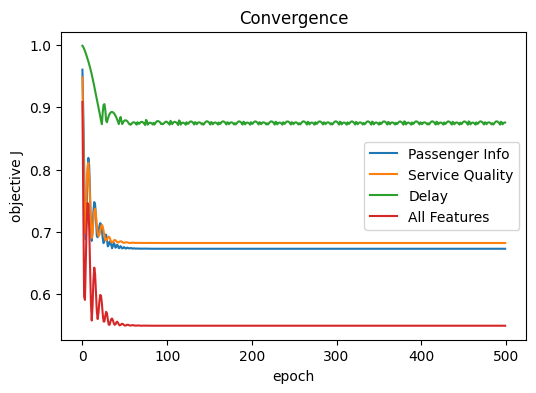

In [46]:
## Convergence plot
plt.figure(figsize=(6, 4))
for name, m in lin_models.items():
    plt.plot(m.history, label=name)
plt.xlabel("epoch"); plt.ylabel("objective J"); plt.legend(); plt.title("Convergence")
plt.show()

In [47]:
## Learned weights (Service Quality)
m = lin_models["Service Quality"]
pd.Series(m.w, index=groups["Service Quality"]).sort_values().round(3)

departure/arrival time convenient   -0.067
gate location                       -0.007
food and drink                       0.039
cleanliness                          0.095
baggage handling                     0.099
checkin service                      0.104
inflight wifi service                0.131
seat comfort                         0.135
on-board service                     0.144
inflight entertainment               0.148
leg room service                     0.155
online boarding                      0.289
dtype: float64

## Part (c): Support vectors per category

In [48]:
## Count support vectors
sv_info = {}
for name in ["Passenger Info", "Service Quality", "Delay"]:
    Xtr, _, ytr, _ = data[name]
    m = lin_models[name]
    sv = m.support_vectors(Xtr, ytr)
    on_margin = np.where(np.isclose(ytr * m.decision_function(Xtr), 1, atol=1e-2))[0]
    sv_info[name] = sv
    print(f"{name:16s} SVs = {len(sv):6d} ({100*len(sv)/len(ytr):.1f}% of train) | on margin (~1) = {len(on_margin)}")

Passenger Info   SVs =  84989 (81.8% of train) | on margin (~1) = 6240
Service Quality  SVs =  82395 (79.3% of train) | on margin (~1) = 1104
Delay            SVs = 102860 (99.0% of train) | on margin (~1) = 1199


In [49]:
# Split SVs into margin vs misclassified
for name, sv in sv_info.items():
    Xtr, _, ytr, _ = data[name]
    marg = ytr[sv] * lin_models[name].decision_function(Xtr[sv])
    print(f"{name:16s} inside margin: {(marg > 0).sum():6d} | misclassified: {(marg <= 0).sum():6d}")

Passenger Info   inside margin:  59175 | misclassified:  25814
Service Quality  inside margin:  61085 | misclassified:  21310
Delay            inside margin:  57601 | misclassified:  45259


## Part (d): Gradient updates for different point types

In [50]:
## Helper that explains one point
def explain_point(model, x, y_i, label):
    f = model.decision_function(x[None, :])[0]
    margin = y_i * f
    if margin >= 1:
        gw_pt, gb_pt = np.zeros_like(x), 0.0
        status = "correct and strictly outside margin (y*f >= 1), hinge = 0"
    else:
        gw_pt, gb_pt = -model.C * y_i * x, -model.C * y_i
        status = ("correct but INSIDE margin (0 < y*f < 1)" if margin > 0
                  else "MISCLASSIFIED (y*f <= 0)") + ", hinge active"
    print(f"--- {label} ---")
    print(f"y*f(x) = {margin:.3f} | {status}")
    print(f"  grad_w from this point (before the 1/n average): {np.round(gw_pt[:4], 3)} ...")
    print(f"  grad_b from this point: {gb_pt:.3f}")

In [51]:
## Pick one point of each kind
m = lin_models["Service Quality"]
Xtr, _, ytr, _ = data["Service Quality"]
marg = ytr * m.decision_function(Xtr)

i_out = np.where(marg > 1.5)[0][0]
i_in  = np.where((marg > 0) & (marg < 1))[0][0]
i_mis = np.where(marg < 0)[0][0]

In [52]:
# Show the three cases
explain_point(m, Xtr[i_out], ytr[i_out], "Correct, outside margin")
explain_point(m, Xtr[i_in],  ytr[i_in],  "Inside the margin")
explain_point(m, Xtr[i_mis], ytr[i_mis], "Misclassified")

--- Correct, outside margin ---
y*f(x) = 1.961 | correct and strictly outside margin (y*f >= 1), hinge = 0
  grad_w from this point (before the 1/n average): [0. 0. 0. 0.] ...
  grad_b from this point: 0.000
--- Inside the margin ---
y*f(x) = 0.147 | correct but INSIDE margin (0 < y*f < 1), hinge active
  grad_w from this point (before the 1/n average): [ 0.203 -0.693 -0.765  0.595] ...
  grad_b from this point: 1.000
--- Misclassified ---
y*f(x) = -0.406 | MISCLASSIFIED (y*f <= 0), hinge active
  grad_w from this point (before the 1/n average): [0.549 0.693 0.765 0.907] ...
  grad_b from this point: -1.000


In [53]:
## Show the weight update on one step
def one_step(model, x, y_i, w, b, lr=0.05):
    margin = y_i * (x @ w + b)
    gw = w - (model.C * y_i * x if margin < 1 else 0)
    gb = -model.C * y_i if margin < 1 else 0.0
    return w - lr * gw, b - lr * gb

w, b = m.w.copy(), m.b
for label, i in [("outside", i_out), ("inside", i_in), ("misclassified", i_mis)]:
    w2, b2 = one_step(m, Xtr[i], ytr[i], w, b)
    print(f"{label:14s} |dw| = {np.linalg.norm(w2 - w):.5f} | db = {b2 - b:+.5f}")

outside        |dw| = 0.02353 | db = +0.00000
inside         |dw| = 0.11045 | db = -0.05000
misclassified  |dw| = 0.14463 | db = +0.05000
